# Hicks-Ray CSTR: forward integration

`drto.dynamic_simulation` (feature 007) frees nothing. It applies the declared
control profiles, fixes the controls, and installs the constant-zero objective,
so the solver is handed the square forward integration of the model exactly as
declared. The horizon is kept.

The declared model is the Hicks-Ray CSTR from [`models/hicks.py`](models/hicks.py).
Holding its controls at their declared steady-state values and integrating from
different starting states shows why this reactor is the standard NMPC example:
the declared setpoint is a real equilibrium, but an unstable one, sitting
between two stable branches. Case 1 starts on it and stays. Case 2 starts just
below it and falls away. The closing cell perturbs both directions.

A simulation carries no cost, so the stage and terminal cost equations leave the
model and there is no stage-cost panel to plot.

## Case 1: started on the declared steady state

With the controls held at `v1_ss` and `v2_ss` and the state started at the
declared target, nothing should move. This is the check that the declared
equilibrium really is one.

In [1]:
import pyomo.environ as pyo
import drto
from models.hicks import hicks
from plotting import plot_states, plot_controls


def simulate(zc0, zt0, v1=None, N=50):
    """Integrate the CSTR forward from (zc0, zt0) with the controls held."""
    m = hicks(N=N)
    m.zc_hat.set_value(zc0)
    m.zt_hat.set_value(zt0)
    pyo.TransformationFactory("dae.collocation").apply_to(
        m, wrt=m.t, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
    pyo.TransformationFactory("drto.dynamic_simulation").apply_to(
        m, controls={"v1": pyo.value(m.v1_ss) if v1 is None else v1,
                     "v2": pyo.value(m.v2_ss)})
    return m


m1 = simulate(0.6416, 0.5387)   # exactly the declared steady state
pyo.SolverFactory("pounce").solve(m1, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpncxs9cqx.pyomo.nl...
Parsed 604 vars, 

   4  0.0000000e+00 1.50e-15 3.06e-14   -8.6 1.14e-13      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 4

                                   (scaled)                 (unscaled)
Objective...............:   0.0000000000000000e+00    0.0000000000000000e+00
Dual infeasibility......:   3.0591889156432461e-14    3.0591889156432461e-14
Constraint violation....:   1.4967710629067480e-15    1.4967710629067480e-15
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059035599891142e-09    2.5059035599891142e-09
Overall NLP error.......:   2.5059035599891142e-09    2.5059035599891142e-09


Number of objective function evaluations             = 6
Number of objective gradient evaluations             = 6
Number of equality constraint evaluations            = 6
Number of inequality constraint evaluations          = 6
Number of equality constraint Jacobian evaluations   = 6
Number of inequality constraint Jacobian evaluations = 6
Number of

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 604, 'Number of variables': 604, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 1.1460716724395752}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

horizon,"t (ContinuousSet, 151 points)"
states,"zc (free), zt (free)"
dynamics,dzc[t] == (1 - zc[t])/(u2sf*v2[t]) - k0*zc[t]*exp(- ea/zt[t]) for t in t
dynamics,dzt[t] == (ztf - zt[t])/(u2sf*v2[t]) + k0*zc[t]*exp(- ea/zt[t]) - a0*u1sf*v1[t]*(zt[t] - ztcw) for t in t
controls,"v1 (piecewise_constant, fixed), v2 (piecewise_constant, fixed)"
initial conditions,zc[0] == zc_hat
initial conditions,zt[0] == zt_hat
steady-state targets,"zc_ss (of zc), zt_ss (of zt)"
steady-state control targets,"v1_ss (of v1), v2_ss (of v2)"


In [3]:
tN = m1.t.last()
print(f"start    zc {pyo.value(m1.zc[0]):.5f}   zt {pyo.value(m1.zt[0]):.5f}")
print(f"end      zc {pyo.value(m1.zc[tN]):.5f}   zt {pyo.value(m1.zt[tN]):.5f}")
print(f"declared zc {pyo.value(m1.zc_ss):.5f}   zt {pyo.value(m1.zt_ss):.5f}")

start    zc 0.64160   zt 0.53870
end      zc 0.64125   zt 0.53896
declared zc 0.64160   zt 0.53870


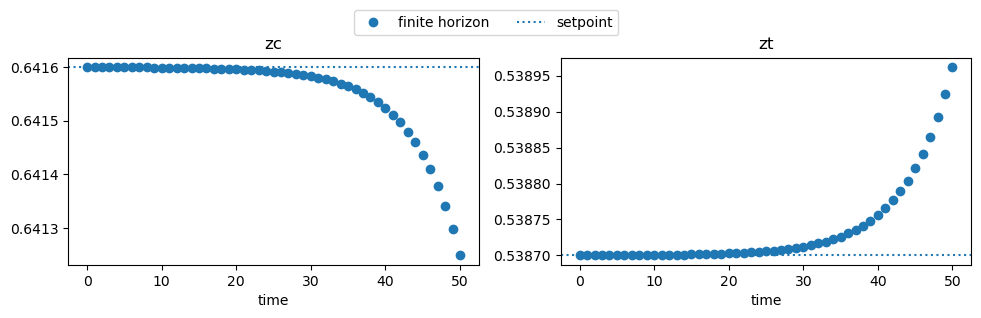

In [4]:
plot_states(m1);

## Case 2: started just below it

The model's own initial state (`zc_hat` 0.625, `zt_hat` 0.525) sits a little
below the target. With the same held controls the reactor does not return to
the setpoint, it cools and runs out to the low-conversion branch. The setpoint
is unstable in open loop, which is exactly what `drto.dynamic_optimization`
(feature 006) is for.

In [5]:
m2 = simulate(0.625, 0.525)   # the model's declared initial state
pyo.SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp67xd2vqb.pyomo.nl...
Parsed 604 vars, 

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  40r 0.0000000e+00 1.24e-02 1.83e+03   -3.8 9.76e-02    2.0 6.01e-04 9.85e-05f  1
  41r 0.0000000e+00 1.24e-02 1.83e+03   -3.8 7.61e-01      - 1.54e-04 4.39e-05h  1
  42r 0.0000000e+00 1.24e-02 1.82e+03   -3.8 1.13e+00      - 1.70e-02 2.60e-04f  1
  43r 0.0000000e+00 1.24e-02 1.82e+03   -3.8 8.14e-02    2.5 2.83e-03 1.82e-05h  1
  44r 0.0000000e+00 1.21e-02 1.83e+03   -3.8 2.48e-01      - 5.65e-04 2.51e-02f  1
  45r 0.0000000e+00 1.21e-02 1.71e+03   -3.8 8.81e-01    2.0 1.28e-03 3.32e-05h  1
  46r 0.0000000e+00 1.21e-02 1.64e+03   -3.8 9.07e-02    2.4 3.39e-05 8.95e-05f  1
  47r 0.0000000e+00 1.21e-02 2.04e+03   -3.8 5.25e-01    1.9 1.26e-01 1.74e-04f  1
  48r 0.0000000e+00 1.21e-02 2.63e+03   -3.8 8.85e-02      - 3.52e-04 4.61e-04f  1
  49r 0.0000000e+00 1.21e-02 2.63e+03   -3.8 2.14e-01      - 1.69e-05 2.66e-04f  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  50

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 604, 'Number of variables': 604, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 1.3412346839904785}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

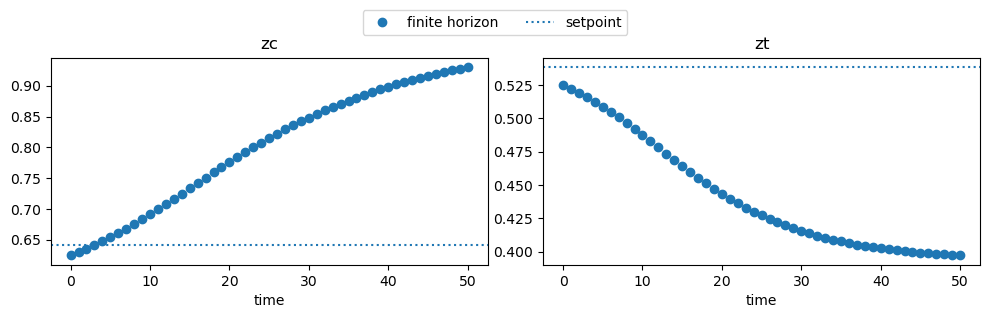

In [6]:
plot_states(m2);

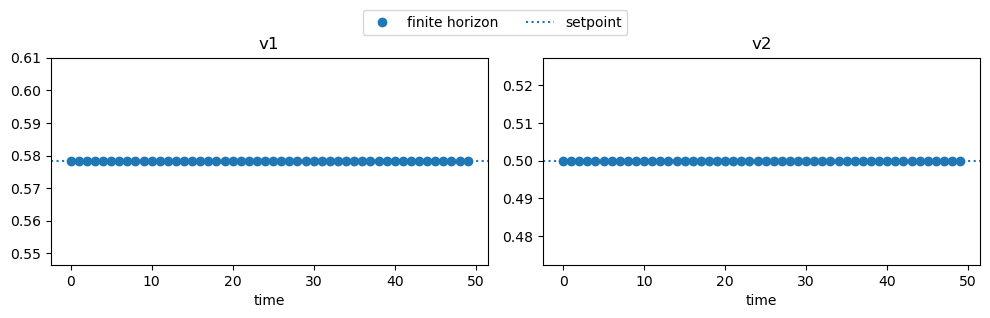

In [7]:
plot_controls(m2);

## Both directions, and the per-point control option

Perturbed the other way the reactor runs to the hot, high-conversion branch, so
the declared setpoint is a saddle between the two. The last row also exercises
the sequence form of the `controls` option: one value per free point the
applied profile leaves, here fifty piecewise-constant coolant moves stepping up
at sample ten.

In [8]:
v1_ss = pyo.value(hicks(N=1).v1_ss)
step = [v1_ss] * 10 + [v1_ss * 1.15] * 40   # more coolant from sample 10 on

runs = (("on the setpoint      ", 0.6416, 0.5387, None),
        ("below it             ", 0.625, 0.525, None),
        ("above it             ", 0.655, 0.552, None),
        ("below it, coolant step", 0.625, 0.525, step))

for label, zc0, zt0, v1 in runs:
    m = simulate(zc0, zt0, v1=v1)
    pyo.SolverFactory("pounce").solve(m)
    t = m.t.last()
    print(f"{label}  start ({zc0:.4f}, {zt0:.4f})"
          f"   end ({pyo.value(m.zc[t]):.5f}, {pyo.value(m.zt[t]):.5f})")

on the setpoint        start (0.6416, 0.5387)   end (0.64125, 0.53896)


below it               start (0.6250, 0.5250)   end (0.93045, 0.39719)


above it               start (0.6550, 0.5520)   end (0.10193, 0.76676)


below it, coolant step  start (0.6250, 0.5250)   end (0.93386, 0.39436)
